In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import cvxpy as cp
import os
from google.colab import drive
import warnings

# Tắt tất cả các warning liên quan đến user (bao gồm cái của cvxpy)
warnings.filterwarnings("ignore", category=UserWarning)

# HOẶC: Chỉ tắt đúng cái warning về ma trận này (An toàn hơn)
warnings.filterwarnings("ignore", message=".*matrix multiplication.*")

# ==========================================
# 1. MOUNT GOOGLE DRIVE
# ==========================================
# Bước này sẽ yêu cầu bạn cấp quyền truy cập Drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
# --- CES / Linear (m = CES exponent, m=1 → Linear, m='inf' → Leontief-like max) ---
def calculate_ces_utility(allocation_vec, valuations_vec, m=1):
    prod = valuations_vec * allocation_vec

    if m == 'inf':
        return np.max(prod, axis=1)

    sum_pow = np.sum(np.power(prod, m), axis=1)
    return np.power(sum_pow, 1/m)


# --- COBB–DOUGLAS UTILITY ---
def calculate_cd_utility(allocation_vec, valuations_vec):
    eps = 1e-12

    v = np.atleast_2d(valuations_vec)
    x = np.atleast_2d(allocation_vec)

    # Normalize weights α_j = v_j / sum(v)
    weights = v / (np.sum(v, axis=1, keepdims=True) + eps)

    # log utility = Σ α_j log(x_j)
    log_u = np.sum(weights * np.log(x + eps), axis=1)

    u = np.exp(log_u)

    return float(u[0]) if valuations_vec.ndim == 1 else u


# --- LEONTIEF UTILITY ---
def calculate_leo_utility(allocation_vec, valuations_vec):
    eps = 1e-12

    v = np.atleast_2d(valuations_vec)
    x = np.atleast_2d(allocation_vec)

    # min_j (x_j / v_j)
    ratio = x / (v + eps)
    u = np.min(ratio, axis=1)

    return float(u[0]) if valuations_vec.ndim == 1 else u


## 1a

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import os
import time

# ==============================================================================
# 1. CORE FUNCTIONS
# ==============================================================================

def build_A_matrix(n_goods, n_slots):
    """Tạo ma trận ánh xạ Goods -> Slots"""
    A = np.zeros((n_slots, n_goods))
    for j in range(n_goods):
        A[j % n_slots, j] = 1.0
    return A

import numpy as np
import cvxpy as cp

def buyer_best_response_cvx(v_i, p, A, q_i, B_i, utility_type="Linear"):
    """
    Giải bài toán tối ưu hóa tiện ích của người mua i.
    Linear: Dùng Closed-form (Siêu nhanh).
    Các loại khác: Dùng Solver CVXPY (như cũ).
    """
    m_goods = len(v_i)

    # 1. Tính Giá Hiệu Dụng (Effective Price)
    # p: giá gốc, A.T @ q_i: giá tắc nghẽn
    effective_price = p + (A.T @ q_i)

    # An toàn: Đảm bảo giá không <= 0 để tránh chia cho 0
    # (Thực tế giá có thể rất nhỏ nhưng phải dương)
    safe_price = np.maximum(effective_price, 1e-12)

    # =========================================================
    # OPTIMIZATION 1: LINEAR UTILITY (CLOSED-FORM)
    # =========================================================
    if utility_type == "Linear":
        # Chiến thuật: Bang-per-buck (Ngon-Bổ-Rẻ nhất thì mua tất tay)
        # Tính tỷ lệ lợi ích / giá
        bang_per_buck = v_i / safe_price

        # Tìm chỉ số món hàng có tỷ lệ cao nhất
        best_idx = np.argmax(bang_per_buck)

        # Tạo vector kết quả
        x_val = np.zeros(m_goods)

        # Dồn toàn bộ ngân sách cho món đó
        x_val[best_idx] = B_i / safe_price[best_idx]

        return x_val  # <--- TRẢ VỀ NGAY (Không chạy Solver đoạn dưới)

    # =========================================================
    # OPTIMIZATION 2: CÁC LOẠI KHÁC (Dùng CVXPY Solver)
    # =========================================================
    x = cp.Variable(m_goods, nonneg=True)
    constraints = [effective_price @ x <= B_i]

    # 2. Cobb–Douglas utility
    if utility_type == "Cobb-Douglas":
        # Lưu ý: Cần chuẩn hóa alpha nếu chưa chuẩn hóa
        sum_v = np.sum(v_i)
        alpha = np.divide(v_i, sum_v, out=np.zeros_like(v_i), where=(sum_v > 1e-12))

        log_util = cp.sum(cp.multiply(alpha, cp.log(x + 1e-12)))
        objective = cp.Maximize(B_i * log_util)

    # 3. Leontief utility
    elif utility_type == "Leontief":
        # Logic Leontief cũ của bạn
        inv_v = np.divide(1.0, v_i, out=np.full_like(v_i, 1e30), where=(v_i > 1e-12))
        objective = cp.Maximize(B_i * cp.log(cp.min(cp.multiply(x, inv_v)) + 1e-12))

    # Nếu không phải Linear thì mới chạy Solver ở đây
    prob = cp.Problem(objective, constraints)
    try:
        prob.solve(solver=cp.ECOS, verbose=False)
    except:
        try:
            prob.solve(solver=cp.SCS, verbose=False)
        except:
            # print(f"Solver failed. Status: {prob.status}")
            return np.zeros(m_goods)

    if x.value is None:
        return np.zeros(m_goods)

    return x.value

def solve_centralized_optimal_fair(valuations, budgets, supply_s, b_mat, A, utility_type="Linear"):
    """
    Returns:
        optimal_value (float): Giá trị hàm mục tiêu tối ưu.
        optimal_X (np.ndarray): Ma trận phân bổ tối ưu (N x M).
    """
    n, m = valuations.shape
    X = cp.Variable((n, m), nonneg=True)

    constraints = [
        cp.sum(X, axis=0) <= supply_s
    ]
    for i in range(n):
        constraints.append(A @ X[i] <= b_mat[i])

    # --- XÂY DỰNG OBJECTIVE ---
    if utility_type == "Linear":
        utilities = cp.sum(cp.multiply(valuations, X), axis=1)
        primal_utility = cp.sum(cp.multiply(budgets, cp.log(utilities + 1e-12)))
    elif utility_type == "Cobb-Douglas":
        eps = 1e-12
        alpha = valuations / (np.sum(valuations, axis=1, keepdims=True) + eps)
        log_utilities = cp.sum(cp.multiply(alpha, cp.log(X + eps)), axis=1)
        primal_utility = cp.sum(cp.multiply(budgets, log_utilities))
    elif utility_type == "Leontief":
        # Lưu ý: Leontief trong CVXPY có thể phức tạp/chậm với quy mô lớn
        ratios = cp.multiply(X, 1.0 / (valuations + 1e-12))
        utilities = cp.min(ratios, axis=1)
        primal_utility = cp.sum(cp.multiply(budgets, cp.log(utilities + 1e-12)))

    objective = cp.Maximize(primal_utility)
    prob = cp.Problem(objective, constraints)

    print(f"--- Solving Centralized Fair Problem ({utility_type}) ---")
    try:
        prob.solve(solver=cp.ECOS, verbose=False)
    except:
        prob.solve(solver=cp.SCS, verbose=False)

    # TRẢ VỀ: (Giá trị mục tiêu, Ma trận X tối ưu)
    return prob.value, X.value


# HÀM TỔNG QUÁT CÓ SUPPLY
def one_sample_sgd_fastlog(
    A: np.ndarray,          # Ma trận ràng buộc Slot (T x M)
    b: np.ndarray,          # Vector Capacity của Slot (N x T)
    supply_s: np.ndarray,   # <--- THAM SỐ MỚI: Vector Supply (M,)
    q0: np.ndarray,         # Dual q khởi tạo (N x T)
    valuations: np.ndarray, # Valuations (N x M)
    budgets: np.ndarray,    # Budgets (N,)
    p0: np.ndarray,         # Dual p khởi tạo (M,)
    lr_p=0.01, lr_q=0.01,   # Learning rates
    num_iters=1000,
    seed=42,
    log_freq=10, utility_type="Linear"
):
    """
    Chạy thuật toán SGD để tìm điểm cân bằng thị trường.
    Hỗ trợ Supply tổng quát và ghi log chi tiết.
    """
    rng = np.random.default_rng(seed)
    n, m = valuations.shape

    # Copy để không ảnh hưởng dữ liệu gốc
    p = p0.astype(float).copy()
    q = q0.astype(float).copy()

    # --- 1. KHỞI TẠO (WARM START) ---

    X = np.zeros((n, m))
    util = np.zeros(n)

    # Tính X ban đầu cho mọi user
    for j in range(n):
        X[j] = buyer_best_response_cvx(valuations[j], p, A, q[j], budgets[j], utility_type) ### maybe already good
        if utility_type == "Linear":
            util[j] = valuations[j] @ X[j]
        elif utility_type == "Cobb-Douglas":
            util[j] = float(calculate_cd_utility(X[j], valuations[j]))
        elif utility_type == "Leontief":
            util[j] = float(calculate_leo_utility(X[j], valuations[j]))

    # Tính Tổng cầu ban đầu (D)
    D = X.sum(axis=0)

    # --- 2. GHI LOG TRẠNG THÁI BAN ĐẦU (t=0) ---
    # Việc này giúp biểu đồ của bạn xuất phát cùng 1 điểm
    obj_hist = []

    term_p = np.sum(p * supply_s)     # p * Supply
    term_q = np.sum(q * b)            # q * Capacity
    term_u = np.sum(budgets * np.log(util + 1e-12)) # Utility
    obj_0 = term_p + term_q + term_u
    obj_hist.append(obj_0)

    print(f"--- Start SGD ({num_iters} iterations) | Initial Obj: {obj_0:.2f} ---")
    t0 = time.perf_counter()

    # Chỉ cần lưu lịch sử Allocation để tính Residual

    # --- GHI LOG TẠI T=0 ---
    real_allocation_hist.append(X.copy())

    # --- 3. VÒNG LẶP CHÍNH ---
    for t in range(1, num_iters + 1):
        # A. Chọn ngẫu nhiên 1 user
        i = int(rng.integers(n))

        # B. Cập nhật Demand (Incremental Update)
        D -= X[i] # Trừ cầu cũ

        # C. Tìm Best Response mới
        x_new = buyer_best_response_cvx(valuations[i], p, A, q[i], budgets[i], utility_type)

        # Kiểm tra nếu solver thất bại
        if x_new is None:
            print(f"Lỗi Solver ở SGD iter {t} cho buyer {i}, bỏ qua bước này.")
            D += X[i] # Thêm lại giá trị cũ
            continue # Bỏ qua vòng lặp này

        # Cập nhật X và Utility
        X[i] = x_new
        util[i] = valuations[i] @ x_new
        if utility_type == "Linear":
            util[i] = valuations[i] @ X[i]
        elif utility_type == "Cobb-Douglas":
            util[i] = calculate_cd_utility(X[i], valuations[i])
        elif utility_type == "Leontief":
            util[i] = calculate_leo_utility(X[i], valuations[i])

        D += x_new # Cộng cầu mới

        # D. TÍNH GRADIENT
        # Gradient của p: (Tổng Cầu - Tổng Cung)
        # Nếu D > S -> g_p > 0 -> p cần tăng
        g_p = D - supply_s

        # Gradient của q_i: (Tải trọng cá nhân - Capacity cá nhân)
        # Load tại slot = A * x
        load_i = A @ x_new
        g_q_i = load_i - b[i]

        # E. CẬP NHẬT BIẾN DUAL (Gradient Ascent cho bài toán Dual)
        # Decay Learning Rate: 1 / sqrt(t)
        alpha = lr_p / np.sqrt(t)
        beta  = lr_q / np.sqrt(t)

        # p = p + alpha * (D - S)
        p = np.maximum(0, p + alpha * g_p)

        # q = q + beta * (Load - Cap)
        q[i] = np.maximum(0, q[i] + beta * g_q_i)

        # F. GHI LOG ĐỊNH KỲ
        if t % log_freq == 0:
            # Tính Objective Value
            term_p = np.sum(p * supply_s) # Sử dụng supply_s truyền vào
            term_q = np.sum(q * b)
            term_u = np.sum(budgets * np.log(util + 1e-12))
            obj = term_p + term_q + term_u - np.sum(budgets)

            obj_hist.append(obj)
            real_allocation_hist.append(X.copy())

            # In tiến độ (Optional)
            if t % 10 == 0:
                print(f"Iter {t}/{num_iters} | Obj: {obj:.4f}")

    total_time = time.perf_counter() - t0
    print(f"--- Finished in {total_time:.2f}s ---")

    return obj_hist, real_allocation_hist

# ==============================================================================
# 2. MAIN SCRIPT
# ==============================================================================

# --- A. LOAD VALUATIONS ---
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_10u_24i"
print(f"--- Loading Data ---")
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path):
        valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
    print(f"✓ Valuations Shape: {valuations.shape}")
except:
    print("⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)")
    valuations = np.random.rand(10, 24) + 0.1
valuations /= 10

N_USERS, M_GOODS = valuations.shape
T_SLOTS = 4

--- Loading Data ---
✓ Valuations Shape: (10, 24)


In [4]:
# ==============================================================================
# 3. PARAMETER
# ==============================================================================
np.random.seed(1)

# [1] Budgets
budgets = np.ones(N_USERS) * 10

# [2] Supply
supply_s = np.random.uniform(5, 10, M_GOODS)

# [3] Capacity (Ma trận N x T)
capacity_b = np.random.uniform(1, 4, (N_USERS, T_SLOTS))

# Matrix A
if M_GOODS % T_SLOTS == 0:
    A_matrix = build_A_matrix(M_GOODS, T_SLOTS)
else:
    A_matrix = np.zeros((T_SLOTS, M_GOODS))

print(f"\n--- Params Check ---")
print(f"Total Budget: {np.sum(budgets):.2f}")
print(f"Supply Sum: {np.sum(supply_s):.2f}")
NUM_ITERS = 150000
LOG_FREQ = 10


--- Params Check ---
Total Budget: 100.00
Supply Sum: 170.60


In [9]:
import pickle
import os
import numpy as np

obj_solver_hist = []
alloc_solver_hist = []
for i in range(1000):
    target_optimal_val, target_optimal_X = solve_centralized_optimal_fair(
        valuations, budgets, supply_s, capacity_b, A_matrix, utility_type="Linear"
    )
    print(f"   ★ Target Dual Optimal (V*): {target_optimal_val:.4f}")
    if target_optimal_X is not None:
        print(f"   ★ Optimal Allocation Shape (X*): {target_optimal_X.shape}")
    alloc_solver_hist.append(np.linalg.norm(target_optimal_X, 'fro'))
    obj_solver_hist.append(target_optimal_val)

--- Solving Centralized Fair Problem (Linear) ---
   ★ Target Dual Optimal (V*): -63.9093
   ★ Optimal Allocation Shape (X*): (10, 24)
--- Solving Centralized Fair Problem (Linear) ---
   ★ Target Dual Optimal (V*): -63.9093
   ★ Optimal Allocation Shape (X*): (10, 24)
--- Solving Centralized Fair Problem (Linear) ---
   ★ Target Dual Optimal (V*): -63.9093
   ★ Optimal Allocation Shape (X*): (10, 24)
--- Solving Centralized Fair Problem (Linear) ---
   ★ Target Dual Optimal (V*): -63.9093
   ★ Optimal Allocation Shape (X*): (10, 24)
--- Solving Centralized Fair Problem (Linear) ---
   ★ Target Dual Optimal (V*): -63.9093
   ★ Optimal Allocation Shape (X*): (10, 24)
--- Solving Centralized Fair Problem (Linear) ---
   ★ Target Dual Optimal (V*): -63.9093
   ★ Optimal Allocation Shape (X*): (10, 24)
--- Solving Centralized Fair Problem (Linear) ---
   ★ Target Dual Optimal (V*): -63.9093
   ★ Optimal Allocation Shape (X*): (10, 24)
--- Solving Centralized Fair Problem (Linear) ---
   ★ 

SolverError: Solver 'SCS' failed. Try another solver, or solve with verbose=True for more information.

In [8]:
print(alloc_solver_hist)

[np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.float64(14.78301753936674), np.floa

In [ ]:
import pickle
import os
import numpy as np

# ==============================================================================
# 4. EXPERIMENT RUNNER (ALL UTILITIES) - UPDATED VERSION
# ==============================================================================

# Cấu hình chung
UTILITY_TYPES = ["Linear"]
NUM_ITERS = 1000000
LOG_FREQ = 10
SAVE_DIR = "/content/drive/MyDrive/EV_charging_project/experiment_results/Fig1_20/12"

# Tạo thư mục nếu chưa tồn tại
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)
    print(f"📂 Đã tạo thư mục: {SAVE_DIR}")

# Khởi tạo biến Dual (Reset cho mỗi loop để công bằng)
p0_init = np.ones(M_GOODS) * 1.0  # Khởi tạo giá = 1
q0_init = np.zeros((N_USERS, T_SLOTS))

print(f"🚀 Bắt đầu chạy thí nghiệm cho {len(UTILITY_TYPES)} loại hàm Utility...\n")

for u_type in UTILITY_TYPES:
    print(f"==================================================")
    print(f"▶️  PROCESSING: {u_type.upper()}")
    print(f"==================================================")

    # --- BƯỚC 1: TÌM V* VÀ X* (GROUND TRUTH - CENTRALIZED) ---
    try:
        # CẬP NHẬT: Hứng cả 2 giá trị (Optimal Value và Optimal Allocation)
        target_optimal_val, target_optimal_X = solve_centralized_optimal_fair(
            valuations, budgets, supply_s, capacity_b, A_matrix, utility_type=u_type
        )
        print(f"   ★ Target Dual Optimal (V*): {target_optimal_val:.4f}")
        if target_optimal_X is not None:
            print(f"   ★ Optimal Allocation Shape (X*): {target_optimal_X.shape}")

    except Exception as e:
        print(f"   ⚠️ Lỗi Solver Tập trung: {e}")
        target_optimal_val = None
        target_optimal_X = None

    # --- BƯỚC 2: CHẠY SGD (DISTRIBUTED) ---
    current_lr = 0.025

    # CẬP NHẬT: Hứng cả lịch sử Objective và Allocation (X_t)
    # alloc_hist[0] sẽ là X_0
    obj_hist, alloc_hist = one_sample_sgd_fastlog(
        A=A_matrix,
        b=capacity_b,
        supply_s=supply_s,
        q0=q0_init.copy(),      # Copy để không bị dính dữ liệu vòng lặp trước
        valuations=valuations,
        budgets=budgets,
        p0=p0_init.copy(),      # Copy
        lr_p=current_lr,
        lr_q=current_lr,
        num_iters=NUM_ITERS,
        log_freq=LOG_FREQ,
        utility_type=u_type
    )

    # --- BƯỚC 3: LƯU KẾT QUẢ ---
    # Chuẩn hóa tên file: "Linear" -> "linear", "Cobb-Douglas" -> "cobb_douglas"
    safe_name = u_type.lower().replace("-", "_")
    file_name = f"experiment_data_{safe_name}.pkl"
    file_path = os.path.join(SAVE_DIR, file_name)

    # Đóng gói dữ liệu đầy đủ
    result_package = {
        "utility_type": u_type,

        # Dữ liệu từ SGD
        "obj_hist": obj_hist,          # Lịch sử giá trị hàm mục tiêu
        "alloc_hist": alloc_hist,      # Lịch sử phân bổ X (gồm cả X_0)

        # Dữ liệu đối chứng (Ground Truth)
        "optimal_val": target_optimal_val,
        "optimal_X": target_optimal_X, # Ma trận X tối ưu

        # Tham số cấu hình
        "params": {
            "lr": current_lr,
            "iters": NUM_ITERS,
            "log_freq": LOG_FREQ
        }
    }

    with open(file_path, 'wb') as f:
        pickle.dump(result_package, f)

    print(f"   ✅ Đã lưu: {file_name}")
    print(f"   (Final SGD Value: {obj_hist[-1]:.4f})")
    print(f"   (Allocations recorded: {len(alloc_hist)} snapshots)\n")

print("🏁 HOÀN THÀNH TẤT CẢ THÍ NGHIỆM!")

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
Iter 950070/1000000 | Obj: -63.7497
Iter 950080/1000000 | Obj: -63.7911
Iter 950090/1000000 | Obj: -63.8088
Iter 950100/1000000 | Obj: -63.8154
Iter 950110/1000000 | Obj: -63.7933
Iter 950120/1000000 | Obj: -63.7656
Iter 950130/1000000 | Obj: -63.7831
Iter 950140/1000000 | Obj: -63.7681
Iter 950150/1000000 | Obj: -63.7742
Iter 950160/1000000 | Obj: -63.8214
Iter 950170/1000000 | Obj: -63.8436
Iter 950180/1000000 | Obj: -63.7902
Iter 950190/1000000 | Obj: -63.7596
Iter 950200/1000000 | Obj: -63.7657
Iter 950210/1000000 | Obj: -63.7516
Iter 950220/1000000 | Obj: -63.7722
Iter 950230/1000000 | Obj: -63.7673
Iter 950240/1000000 | Obj: -63.7680
Iter 950250/1000000 | Obj: -63.7530
Iter 950260/1000000 | Obj: -63.7648
Iter 950270/1000000 | Obj: -63.7882
Iter 950280/1000000 | Obj: -63.7773
Iter 950290/1000000 | Obj: -63.7530
Iter 950300/1000000 | Obj: -63.7547
Iter 950310/1000000 | Obj: -63.7089
Iter 950320/1000000 | Obj: -63.7054
Iter 95

--- Loading & Plotting Data ---
⚠️ Không tìm thấy file: /content/drive/MyDrive/EV_charging_project/experiment_results/Fig1_20/12/experiment_data_leontief.pkl


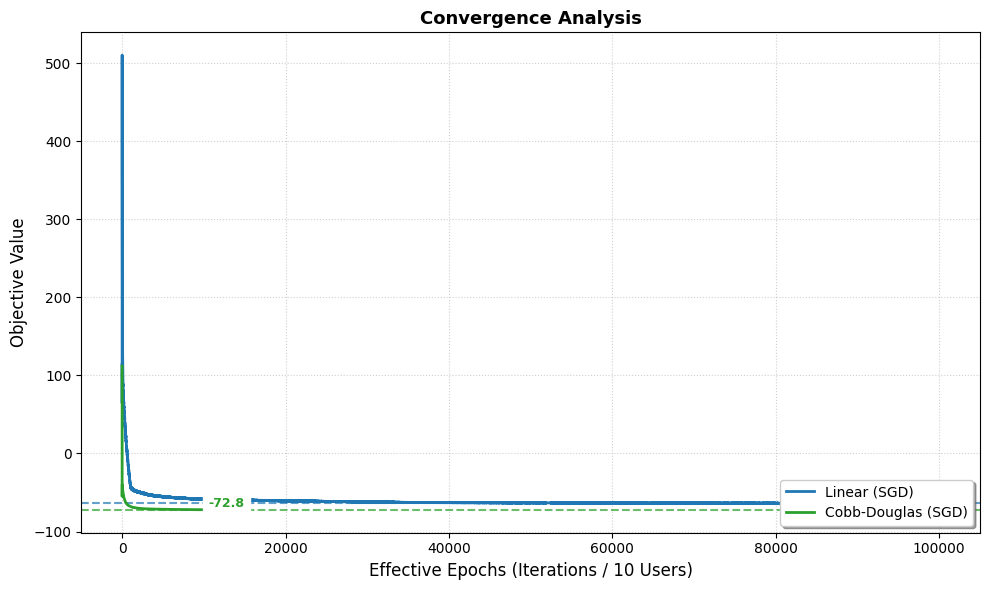

In [ ]:
import matplotlib.pyplot as plt
import pickle
import os
import numpy as np

# ==============================================================================
# 5. VẼ BIỂU ĐỒ SO SÁNH (SINGLE CHART - OBJECTIVE VALUE)
# ==============================================================================

# Cấu hình đường dẫn
SAVE_DIR = "/content/drive/MyDrive/EV_charging_project/experiment_results/Fig1_20/12"
UTILITY_LIST = ["Linear", "Cobb-Douglas", "Leontief"]

# Cấu hình hiển thị
plt.figure(figsize=(10, 6)) # Kích thước chuẩn cho 1 biểu đồ

colors = {
    "Linear": "#1f77b4",       # Xanh dương
    "Cobb-Douglas": "#2ca02c", # Xanh lá
    "Leontief": "#d62728"      # Đỏ
}

print("--- Loading & Plotting Data ---")

# Biến tạm để lưu số user cho label trục X
label_n_users = 10

for u_name in UTILITY_LIST:
    # 1. Tạo tên file và load dữ liệu
    safe_name = u_name.lower().replace("-", "_")
    file_path = os.path.join(SAVE_DIR, f"experiment_data_{safe_name}.pkl")

    if not os.path.exists(file_path):
        print(f"⚠️ Không tìm thấy file: {file_path}")
        continue

    with open(file_path, 'rb') as f:
        data = pickle.load(f)

    # 2. Lấy dữ liệu an toàn từ Dictionary
    hist = data["obj_hist"]
    optimal_val = data["optimal_val"]

    # Lấy tham số cấu hình từ file pickle (để code tự động hoá)
    params = data.get("params", {})
    log_freq = params.get("log_freq", 10) # Default là 10 nếu không thấy

    # Tự động xác định N_USERS từ dữ liệu Optimal_X (nếu có)
    if data.get("optimal_X") is not None:
        n_users = data["optimal_X"].shape[0]
    else:
        n_users = 10 # Fallback mặc định

    label_n_users = n_users # Cập nhật cho label trục X

    # 3. Tính toán trục X (Epochs)
    # Epoch = (Số bước lặp) / (Số người dùng)
    steps = np.arange(len(hist)) * log_freq
    epochs = steps / n_users

    c = colors[u_name] # Lấy màu tương ứng

    # 4. Vẽ đường SGD (Nét liền)
    plt.plot(epochs, hist, color=c, linestyle='-', linewidth=2,
             label=f'{u_name} (SGD)')

    # 5. Vẽ đường Optimal (Nét đứt)
    if optimal_val is not None:
        plt.axhline(y=optimal_val, color=c, linestyle='--', linewidth=1.5, alpha=0.7)

        # Ghi chú giá trị (Annotate) ở bên phải biểu đồ
        plt.text(epochs[-1], optimal_val, f'{optimal_val:.1f}',
                 verticalalignment='bottom', horizontalalignment='right',
                 color=c, fontweight='bold', fontsize=9, backgroundcolor='white')

# ==============================================================================
# TRANG TRÍ BIỂU ĐỒ
# ==============================================================================
plt.xlabel(f'Effective Epochs (Iterations / {label_n_users} Users)', fontsize=12)
plt.ylabel('Objective Value', fontsize=12)
plt.title('Convergence Analysis',
          fontsize=13, fontweight='bold')

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

## 1b

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
num 29.31435969073167
num 28.385837241107822
num 29.73392687861624
num 30.54606129523338
num 28.734948403199315
num 28.68178697180468
num 28.41126819152415
num 28.29461874026082
num 28.6016842850544
num 27.870726027314067
num 26.932135103556412
num 26.212998092602326
num 28.846051034089285
num 28.126550139870098
num 28.70178574163641
num 30.011937350411944
num 27.45008388202566
num 28.033278126714723
num 28.096728686969147
num 27.09126315235785
num 26.31503831726261
num 27.445016156468157
num 28.10079330734837
num 28.290568526397134
num 26.06505051215826
num 26.649114573001906
num 28.21753977369478
num 26.93392500821883
num 26.340917401768735
num 25.021150961540705
num 28.523686989253637
num 27.727109165798428
num 26.198688034667978
num 27.066543937619805
num 26.77504500550304
num 30.034863047940195
num 29.41879088156822
num 28.854968113381357
num 28.35864113560127
num 27.128473491815942
num 26.869777905617774
num 27.210547814963

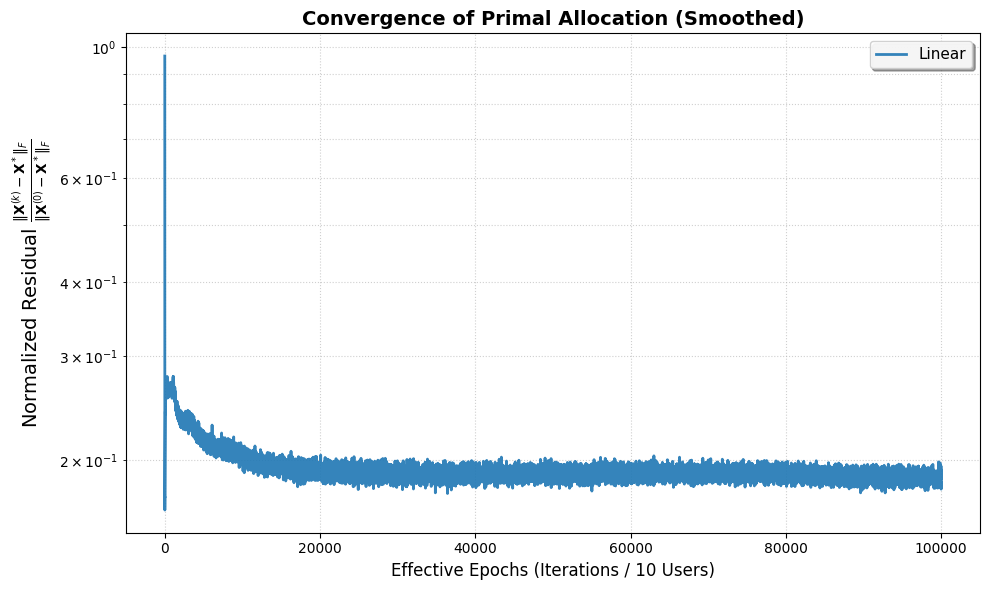

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os

# ==============================================================================
# 1. CẤU HÌNH & KHỞI TẠO
# ==============================================================================
SAVE_DIR = "/content/drive/MyDrive/EV_charging_project/experiment_results/Fig1_20/12"
UTILITY_TYPES = ["Linear"] ##, "CES_8", "Cobb-Douglas", "Leontief"]
WINDOW_SIZE = 10  # Tăng window lên chút để đường vẽ mượt hơn (tuỳ chọn)

# Cấu hình màu và kiểu đường
STYLES = {
    "Linear":       {"color": "#1f77b4", "linestyle": "-",  "label": "Linear"},
    "Cobb-Douglas": {"color": "#2ca02c", "linestyle": "--", "label": "Cobb-Douglas"},
    "Leontief":     {"color": "#d62728", "linestyle": "-.", "label": "Leontief"},
    "CES_8":        {"color": "#9467bd", "linestyle": ":",  "label": "CES (m=8)"}      # Tím
}

plt.figure(figsize=(10, 6))

captured_n_users = 10 # Default fallback

# ==============================================================================
# 2. VÒNG LẶP XỬ LÝ & VẼ
# ==============================================================================
print("--- Processing Convergence Plot ---")

for u_type in UTILITY_TYPES:
    # 1. Load đúng tên file đã lưu ở bước trước
    safe_name = u_type.lower().replace("-", "_")
    file_path = os.path.join(SAVE_DIR, f"experiment_data_{safe_name}.pkl")

    if not os.path.exists(file_path):
        print(f"⚠️ Không tìm thấy file: {file_path}")
        continue

    print(f"   -> Loading: {u_type}...")

    with open(file_path, "rb") as f:
        data = pickle.load(f)

    # 2. Lấy dữ liệu (Sử dụng .get để tránh lỗi key)
    # Lưu ý: Ở bước save, ta lưu key là "optimal_X", không phải "X_star"
    X_star = data.get("optimal_X")
    alloc_hist = data.get("alloc_hist")

    # Lấy tham số cấu hình
    params = data.get("params", {})
    log_freq = params.get("log_freq", 10)

    # Kiểm tra tính hợp lệ
    if X_star is None:
        print(f"      ⚠️ Bỏ qua {u_type}: Không có nghiệm Optimal (X*) để so sánh.")
        continue

    if alloc_hist is None or len(alloc_hist) == 0:
        print(f"      ⚠️ Bỏ qua {u_type}: Không có lịch sử Allocation.")
        continue

    # Lấy N_USERS từ shape thực tế
    n_users_current = X_star.shape[0]
    captured_n_users = n_users_current

    # --- TÍNH TOÁN NORMALIZED RESIDUALS ---
    # Residual = ||X_k - X*|| / ||X_0 - X*||

    # Mẫu số: Khoảng cách tại thời điểm t=0
    X_0 = alloc_hist[0]
    denom = np.linalg.norm(np.ones((10, 24)) * 10 - X_star, 'fro')
    print(denom)

    residuals = []
    for X_k in alloc_hist:
        # Tử số: Khoảng cách tại thời điểm t=k
        num = np.linalg.norm(X_k - X_star, 'fro')
        print("num", num)
        residuals.append(num / denom)

    residuals = np.array(residuals)

    # --- XỬ LÝ SMOOTHING (SMA) ---
    # Chỉ smooth nếu dữ liệu đủ dài
    if len(residuals) >= WINDOW_SIZE:
        residuals_smoothed = np.convolve(
            residuals,
            np.ones(WINDOW_SIZE)/WINDOW_SIZE,
            mode='valid'
        )
        # Cắt trục X tương ứng (SMA làm mất phần đầu)
        # Iterations thực tế
        raw_iterations = np.arange(len(residuals)) * log_freq
        raw_epochs = raw_iterations / n_users_current

        # Cắt trục X để khớp độ dài với residuals_smoothed
        epochs_to_plot = raw_epochs[WINDOW_SIZE - 1:]
        data_to_plot = residuals_smoothed
    else:
        # Nếu dữ liệu ngắn quá thì vẽ raw luôn
        raw_iterations = np.arange(len(residuals)) * log_freq
        epochs_to_plot = raw_iterations / n_users_current
        data_to_plot = residuals

    # --- VẼ ĐƯỜNG CONG (LOG SCALE) ---
    style = STYLES[u_type]
    plt.semilogy(epochs_to_plot, data_to_plot,
                 color=style["color"],
                 linestyle=style["linestyle"],
                 linewidth=2.0,
                 alpha=0.9,
                 label=f'{style["label"]}')

# ==============================================================================
# 3. TRANG TRÍ & HOÀN THIỆN CHART
# ==============================================================================
plt.xlabel(f'Effective Epochs (Iterations / {captured_n_users} Users)', fontsize=12)
plt.ylabel(r'Normalized Residual $\frac{\|\mathbf{X}^{(k)} - \mathbf{X}^*\|_F}{\|\mathbf{X}^{(0)} - \mathbf{X}^*\|_F}$', fontsize=14)
plt.title(f'Convergence of Primal Allocation (Smoothed)', fontsize=14, fontweight='bold')

plt.grid(True, which="both", linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper right', framealpha=0.9, shadow=True)

plt.tight_layout()
plt.show()